# 🗺️ TripAdvisor - Comparaison des modèles de recherche sémantique

Ce notebook compare trois approches de recherche de lieux similaires sur les avis TripAdvisor de Paris :
- **BM25** : baseline lexicale (TF-IDF amélioré)
- **TF-IDF** + cosine model on place documents
- **Word2Vec** : embeddings de mots, pooling par lieu
- **SBERT** (all-MiniLM-L6-v2) : embeddings contextuels de phrases

L'évaluation se fait sur deux niveaux :
- **Level 1** : le lieu recommandé est-il du même type (H/R/A/AP) ?
- **Level 2** : partage-t-il les mêmes sous-catégories fines ?

## 0. Imports & configuration

In [ ]:
import sys, os, random,warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from typing import List, Tuple
sys.path.insert(0, "./src")   # <-- dossier contenant word2vec.py, sbert.py, etc.
import processing
import score as score_module
import word2vec as w2v_module
import sbert as sbert_module
import processing, strategies, bm25, tfidf, evaluation
import importlib
importlib.reload(processing)
importlib.reload(bm25)
importlib.reload(tfidf)
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'BM25': '#4C72B0', 'Word2Vec': '#DD8452', 'SBERT': '#55A868'}
LEVEL_COLORS = {'Level 1': '#4C72B0', 'Level 2': '#C44E52'}

## 1. Chargement des données

In [22]:
DATA_DIR = "./TripAdvisorTrainingDataProject1"
reviews_raw   = pd.read_csv(f"{DATA_DIR}/reviews83325.csv", low_memory=False)
tripadvisor   = pd.read_csv(f"{DATA_DIR}/Tripadvisor.csv", low_memory=False)
reviews = processing.processing_data(reviews_raw, tripadvisor)
print(f"Reviews (EN) : {len(reviews):,}")
print(f"Lieux uniques : {reviews['idplace'].nunique():,}")
print()
print(reviews['typeR'].value_counts())
place_docs = processing.build_place_docs(reviews)
"""Concatenate reviews per place: for each place (idplace), we merge all its cleaned english reviews 
into a single text called place_docs. This converts the dataset from “one row = one review” to “one row = one place,” which matches the project goal (recommend similar places, not similar reviews).
Why we do it: IR models like BM25 and TF-IDF work on a set of documents. 
Here, each place must be a document so the system can rank and recommend places based only on their reviews."""


Reviews (EN) : 153,071
Lieux uniques : 1,835

typeR
A     70059
R     44512
AP    24779
H     13721
Name: count, dtype: int64


'Concatenate reviews per place: for each place (idplace), we merge all its cleaned english reviews \ninto a single text called place_docs. This converts the dataset from “one row = one review” to “one row = one place,” which matches the project goal (recommend similar places, not similar reviews).\nWhy we do it: IR models like BM25 and TF-IDF work on a set of documents. \nHere, each place must be a document so the system can rank and recommend places based only on their reviews.'

In [16]:
print(reviews.columns.tolist())

['idplace', 'typeR', 'activiteSubCategorie', 'activiteSubType', 'restaurantTypeCuisine', 'priceRange']


Meta data table (for evaluation)

In [29]:
meta_cols = ["id", "typeR", "priceRange", "restaurantTypeCuisine", "activiteSubCategorie", "activiteSubType"]

meta = (
    tripadvisor[meta_cols]
    .rename(columns={"id": "idplace"})
    .drop_duplicates("idplace")
    .set_index("idplace")
)

print("Meta:", meta.shape)
meta.head()

Meta: (3761, 5)


,typeR,priceRange,restaurantTypeCuisine,activiteSubCategorie,activiteSubType
idplace,,,,,
188467,A,NaN,NaN,47,163
188468,A,NaN,NaN,47,163
188470,A,NaN,NaN,"26,47,51","34,144"
188471,A,NaN,NaN,26,137
188472,A,NaN,NaN,47,10


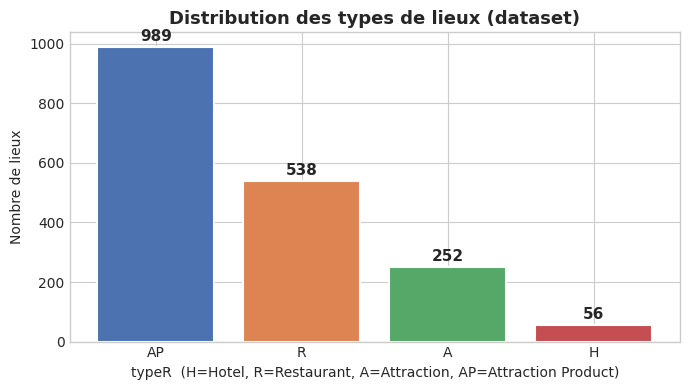

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = reviews.drop_duplicates('idplace')['typeR'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribution des types de lieux (dataset)', fontsize=13, fontweight='bold')
ax.set_xlabel('typeR  (H=Hotel, R=Restaurant, A=Attraction, AP=Attraction Product)')
ax.set_ylabel('Nombre de lieux')
plt.tight_layout()
plt.show()

## 2. Entraînement des modèles

In [6]:
print("On charge Word2Vec (skip-gram, dim=200)...")
w2v_model = Word2Vec.load("word2vec_tripadvisor.model")
print(f" Vocabulaire : {len(w2v_model.wv):,} tokens")

On charge Word2Vec (skip-gram, dim=200)...
 Vocabulaire : 19,824 tokens


In [7]:
print("Calcul des vecteurs de lieux (W2V)...")
w2v_place_ids, w2v_place_vecs = w2v_module.get_place_vectors(reviews, w2v_model,pooling='mean')
print(f"   Shape : {w2v_place_vecs.shape}")

Calcul des vecteurs de lieux (W2V)...
   Shape : (1835, 200)


In [8]:
#SBERT 
print("Encodage SBERT (all-MiniLM-L6-v2)...")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
sbert_place_texts, sbert_place_ids = sbert_module.get_corpus_by_place(reviews)
sbert_place_vecs = sbert_module.encode_places(sbert_place_texts, sbert_model)
print(f"Shape : {sbert_place_vecs.shape}")

Encodage SBERT (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 176.26it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 58/58 [03:51<00:00,  4.00s/it]


Shape : (1835, 384)


- Strategy 1: Word-based truncation (Concatenate + cap to X words)

After building place_docs for each place, we keep only the first X words (e.g., 1200–1500 words) and discard the rest.
The number of reviews per place is highly variable. If we keep all reviews, very popular places produce extremely long documents that can dominate the ranking simply because they contain more terms. Truncating to a fixed maximum length reduces this length/popularity bias while still preserving enough content to describe the place.

- Strategy 2:Top-K TF-IDF keywords 

We compute TF-IDF over the place documents, then for each place we select the K highest-weighted terms (e.g. K=200) and rebuild a reduced place_docs using only these keywords.
Why we do it: Instead of keeping all words (including noisy or generic ones), this strategy retains only the most discriminative terms that best characterize each place. It also normalizes document size across places, reducing the impact of places with many reviews.

In [23]:
# --- Préparation avec tes stratégies ---
print("Application de la stratégie 1 (Troncature)...")
place_docs_S1 = strategies.apply_strategy_truncate(place_docs, max_words=1200)

print("Application de la stratégie 2 (Top-K TF-IDF)...")
place_docs_S2 = strategies.apply_strategy_topk_tfidf_words(place_docs, k_words=200)

Application de la stratégie 1 (Troncature)...
Application de la stratégie 2 (Top-K TF-IDF)...


In [26]:
# --- Entraînement BM25 ---
print("Entraînement BM25...")
MAX_WORDS = 1200
TOPK_WORDS = 200

place_docs_S1 = strategies.apply_strategy_truncate(place_docs, max_words=MAX_WORDS)
place_docs_S2 = strategies.apply_strategy_topk_tfidf_words(place_docs, k_words=TOPK_WORDS)

print("S1:", place_docs_S1.shape, "S2:", place_docs_S2.shape)

Entraînement BM25...
S1: (1835, 2) S2: (1835, 2)


Split places 50/50 + intersect IDs (to avoid KeyError)

In [30]:
query_ids, candidate_ids = evaluation.split_places_50_50(meta.reset_index(), seed=42)

docs_all = set(place_docs_S1["idplace"]).intersection(set(place_docs_S2["idplace"]))
query_ids_eval = query_ids.intersection(docs_all)
candidate_ids_eval = candidate_ids.intersection(docs_all)

print("Query ids:", len(query_ids_eval))
print("Candidate ids:", len(candidate_ids_eval))

Query ids: 914
Candidate ids: 921


Build candidate corpora + query lookup

In [31]:
# Candidate corpora
cand_S1 = place_docs_S1[place_docs_S1["idplace"].isin(candidate_ids_eval)].copy()
cand_S2 = place_docs_S2[place_docs_S2["idplace"].isin(candidate_ids_eval)].copy()

# Query lookup
q_S1 = place_docs_S1[place_docs_S1["idplace"].isin(query_ids_eval)].set_index("idplace")
q_S2 = place_docs_S2[place_docs_S2["idplace"].isin(query_ids_eval)].set_index("idplace")

Fit BM25 and TF-IDF on candidates

In [32]:
# BM25
bm25_S1_model, bm25_S1_ids = bm25.bm25_fit(cand_S1)
bm25_S2_model, bm25_S2_ids = bm25.bm25_fit(cand_S2)

# TF-IDF
tfidf_S1_vec, X_S1, tfidf_S1_ids = tfidf.tfidf_fit(cand_S1, max_features=20000, ngram_range=(1,2), min_df=2)
tfidf_S2_vec, X_S2, tfidf_S2_ids = tfidf.tfidf_fit(cand_S2, max_features=20000, ngram_range=(1,1), min_df=1)

print(" Models fitted.")

 Models fitted.


## 3. Fonctions d'évaluation

In [9]:
def _to_set(val) -> set:
    """Convertit une valeur (str csv, liste, NaN) en set de strings."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return set()
    if isinstance(val, list):
        return {str(v) for v in val}
    return {s.strip() for s in str(val).split(",")}


def _get_l2_tags(pid, place_meta: pd.DataFrame) -> set:
    if pid not in place_meta.index:
        return set()
    row = place_meta.loc[pid]
    tR = row.get("typeR", "")
    if tR == "A":
        return _to_set(row.get("activiteSubCategorie")) | _to_set(row.get("activiteSubType"))
    elif tR == "R":
        return _to_set(row.get("restaurantTypeCuisine"))
    elif tR == "H":
        return _to_set(row.get("priceRange"))
    return set()


def _matches(q_pid, c_pid, place_meta: pd.DataFrame, level: int) -> bool:
    if q_pid not in place_meta.index or c_pid not in place_meta.index:
        return False
    q_type = place_meta.loc[q_pid, "typeR"]
    c_type = place_meta.loc[c_pid, "typeR"]
    if level == 1:
        return q_type == c_type
    if q_type != c_type:
        return False
    q_tags = _get_l2_tags(q_pid, place_meta)
    c_tags = _get_l2_tags(c_pid, place_meta)
    if not q_tags or not c_tags:
        return True  # fallback level-1
    return bool(q_tags & c_tags)


def evaluate_place_model(
    reviews: pd.DataFrame,
    place_ids_arr: np.ndarray,
    place_vecs_arr: np.ndarray,
    level: int = 1,
    random_state: int = 42,
) -> dict:
    """
    Évaluation générique pour tout modèle qui produit des vecteurs de lieux.
    Retourne aussi les listes de sims top-1 et ranking_errors pour les graphiques.
    """
    # métadonnées
    meta_cols = [c for c in ["idplace","typeR","activiteSubCategorie","activiteSubType",
                              "restaurantTypeCuisine","priceRange"] if c in reviews.columns]
    place_meta = reviews[meta_cols].drop_duplicates(subset="idplace").set_index("idplace")

    # split 50/50
    all_ids = place_meta.index.tolist()
    rng = random.Random(random_state)
    rng.shuffle(all_ids)
    mid = len(all_ids) // 2
    train_ids, test_ids = set(all_ids[:mid]), set(all_ids[mid:])

    id2vec = {pid: place_vecs_arr[i] for i, pid in enumerate(place_ids_arr)}
    train_list = [p for p in all_ids[:mid] if p in id2vec]
    test_list  = [p for p in all_ids[mid:] if p in id2vec]
    test_vecs  = np.vstack([id2vec[p] for p in test_list]).astype(np.float32)

    top1_sims, binary_hits, ranking_errors = [], [], []

    for q_pid in train_list:
        q_vec = id2vec[q_pid]
        # cosine : si vecteurs normalisés → produit scalaire, sinon formule complète
        norm_q = np.linalg.norm(q_vec)
        norms_t = np.linalg.norm(test_vecs, axis=1)
        with np.errstate(invalid='ignore', divide='ignore'):
            sims = (test_vecs @ q_vec) / (norms_t * norm_q + 1e-10)
        sims = sims.astype(np.float32)
        ranked_idx = np.argsort(sims)[::-1]
        top1_sims.append(float(sims[ranked_idx[0]]))

        first_pos = next(
            (pos for pos, idx in enumerate(ranked_idx)
             if _matches(q_pid, test_list[idx], place_meta, level)),
            None
        )
        if first_pos is not None:
            binary_hits.append(1 if first_pos == 0 else 0)
            ranking_errors.append(first_pos)

    return {
        "mean_cos_sim":         float(np.mean(top1_sims))      if top1_sims      else float('nan'),
        "max_cos_sim":          float(np.max(top1_sims))       if top1_sims      else float('nan'),
        "eval_score":           float(np.mean(binary_hits))    if binary_hits    else float('nan'),
        "ranking_error":        float(np.mean(ranking_errors)) if ranking_errors else float('nan'),
        "n_queries":            len(train_list),
        "n_queries_with_match": len(ranking_errors),
        # listes brutes pour les graphiques
        "_top1_sims":           top1_sims,
        "_ranking_errors":      ranking_errors,
    }

print("Fonctions d'évaluation définies")

Fonctions d'évaluation définies


Define rank functions

In [33]:
TOP_N = 500  # big enough for L2

def rank_bm25_S1(qid):
    q_text = q_S1.loc[qid, "place_document"]
    ranked = bm25.bm25_rank(bm25_S1_model, bm25_S1_ids, q_text, top_n=TOP_N)
    return [pid for pid, _ in ranked]

def rank_bm25_S2(qid):
    q_text = q_S2.loc[qid, "place_document"]
    ranked = bm25.bm25_rank(bm25_S2_model, bm25_S2_ids, q_text, top_n=TOP_N)
    return [pid for pid, _ in ranked]

def rank_tfidf_S1(qid):
    q_text = q_S1.loc[qid, "place_document"]
    ranked = tfidf.tfidf_rank(tfidf_S1_vec, X_S1, tfidf_S1_ids, q_text, top_n=TOP_N)
    return [pid for pid, _ in ranked]

def rank_tfidf_S2(qid):
    q_text = q_S2.loc[qid, "place_document"]
    ranked = tfidf.tfidf_rank(tfidf_S2_vec, X_S2, tfidf_S2_ids, q_text, top_n=TOP_N)
    return [pid for pid, _ in ranked]

## 4. Lancement de l'évaluation

In [10]:
print("Évaluation Word2Vec — Level 1...")
w2v_l1 = evaluate_place_model(reviews, w2v_place_ids, w2v_place_vecs, level=1)
print(f"eval_score={w2v_l1['eval_score']:.4f}  ranking_error={w2v_l1['ranking_error']:.4f}")

Évaluation Word2Vec — Level 1...
eval_score=0.8637  ranking_error=1.0240


In [11]:
print("Évaluation Word2Vec — Level 2...")
w2v_l2 = evaluate_place_model(reviews, w2v_place_ids, w2v_place_vecs, level=2)
print(f"eval_score={w2v_l2['eval_score']:.4f}  ranking_error={w2v_l2['ranking_error']:.4f}")

Évaluation Word2Vec — Level 2...
eval_score=0.8092  ranking_error=2.2606


In [12]:
print("Évaluation SBERT — Level 1...")
sbert_l1 = evaluate_place_model(reviews, sbert_place_ids, sbert_place_vecs, level=1)
print(f"eval_score={sbert_l1['eval_score']:.4f}  ranking_error={sbert_l1['ranking_error']:.4f}")

Évaluation SBERT — Level 1...
eval_score=0.8680  ranking_error=1.0916


In [13]:
print("Évaluation SBERT — Level 2...")
sbert_l2 = evaluate_place_model(reviews, sbert_place_ids, sbert_place_vecs, level=2)
print(f"eval_score={sbert_l2['eval_score']:.4f}  ranking_error={sbert_l2['ranking_error']:.4f}")

Évaluation SBERT — Level 2...
eval_score=0.8222  ranking_error=3.4318


Evaluate L1 and L2 on 4 combos (TF-IDF and BM25)

In [34]:
# evaluation.py expects meta_df indexed by idplace
meta_idx = meta.copy()

def eval_combo(rank_func, level):
    return evaluation.evaluate_ranking_model(
        query_ids=query_ids_eval,
        rank_function=rank_func,
        meta_df=meta_idx,
        level=level,
        top_n=TOP_N
    )

rows = []

for model_name, strat_name, rf in [
    ("BM25", "S1_truncate", rank_bm25_S1),
    ("BM25", "S2_topk", rank_bm25_S2),
    ("TFIDF", "S1_truncate", rank_tfidf_S1),
    ("TFIDF", "S2_topk", rank_tfidf_S2),
]:
    res_l1 = eval_combo(rf, level=1)
    res_l2 = eval_combo(rf, level=2)
    rows.append({
        "Model": model_name,
        "Strategy": strat_name,
        "L1_mean_error": res_l1["mean_ranking_error"],
        "L2_mean_error": res_l2["mean_ranking_error"],
        "Nb_L1_queries": res_l1["n_queries_evaluated"],
        "Nb_L2_queries": res_l2["n_queries_evaluated"],
    })

results_df = pd.DataFrame(rows)
results_df

,Model,Strategy,L1_mean_error,L2_mean_error,Nb_L1_queries,Nb_L2_queries
0,BM25,S1_truncate,0.637856,7.051948,914,385
1,BM25,S2_topk,0.699125,5.000000,914,385
2,TFIDF,S1_truncate,0.973742,8.859740,914,385
3,TFIDF,S2_topk,0.809628,5.909091,914,385


## 5. Tableau récapitulatif

In [14]:
results = pd.DataFrame([
    {"Modèle": "Word2Vec", "Level": "L1", **{k: v for k, v in w2v_l1.items() if not k.startswith('_')}},
    {"Modèle": "Word2Vec", "Level": "L2", **{k: v for k, v in w2v_l2.items() if not k.startswith('_')}},
    {"Modèle": "SBERT",    "Level": "L1", **{k: v for k, v in sbert_l1.items() if not k.startswith('_')}},
    {"Modèle": "SBERT",    "Level": "L2", **{k: v for k, v in sbert_l2.items() if not k.startswith('_')}},
])

display_cols = ["Modèle", "Level", "eval_score", "ranking_error",
                "mean_cos_sim", "max_cos_sim", "n_queries", "n_queries_with_match"]

styled = (results[display_cols]
    .style
    .format({"eval_score": "{:.4f}", "ranking_error": "{:.4f}",
             "mean_cos_sim": "{:.4f}", "max_cos_sim": "{:.4f}"})
    .background_gradient(subset=["eval_score"], cmap="Greens")
    .background_gradient(subset=["ranking_error"], cmap="Reds_r")
    .set_caption("Résultats d'évaluation — W2V vs SBERT")
)
display(styled)

,Modèle,Level,eval_score,ranking_error,mean_cos_sim,max_cos_sim,n_queries,n_queries_with_match
0,Word2Vec,L1,0.8637,1.0240,0.9719,0.9994,917,917
1,Word2Vec,L2,0.8092,2.2606,0.9719,0.9994,917,917
2,SBERT,L1,0.8680,1.0916,0.7216,0.8949,917,917
3,SBERT,L2,0.8222,3.4318,0.7216,0.8949,917,917


TF-IDF and BM25 for both strategies:

In [35]:
results_df

,Model,Strategy,L1_mean_error,L2_mean_error,Nb_L1_queries,Nb_L2_queries
0,BM25,S1_truncate,0.637856,7.051948,914,385
1,BM25,S2_topk,0.699125,5.000000,914,385
2,TFIDF,S1_truncate,0.973742,8.859740,914,385
3,TFIDF,S2_topk,0.809628,5.909091,914,385


## 6. Graphiques de comparaison

### 6.1 Bar chart — eval_score et ranking_error

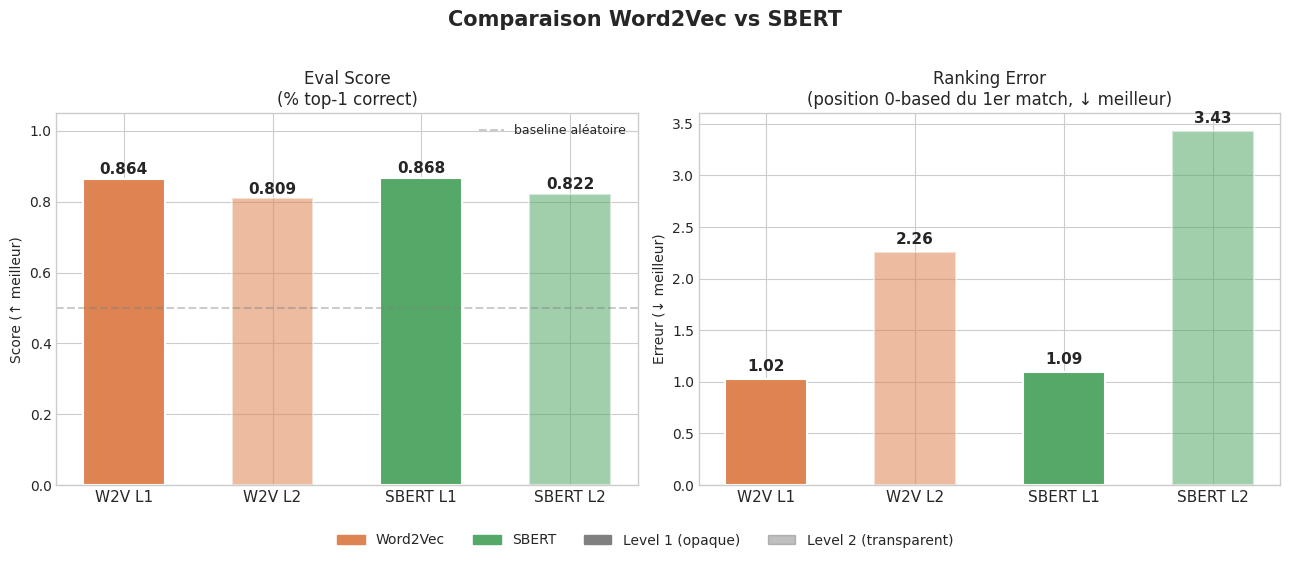

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparaison Word2Vec vs SBERT', fontsize=15, fontweight='bold', y=1.02)
labels  = ['W2V L1', 'W2V L2', 'SBERT L1', 'SBERT L2']
colors  = [PALETTE['Word2Vec'], PALETTE['Word2Vec'], PALETTE['SBERT'], PALETTE['SBERT']]
alphas  = [1.0, 0.55, 1.0, 0.55]
x = np.arange(len(labels))
ax = axes[0]
vals = [w2v_l1['eval_score'], w2v_l2['eval_score'],
        sbert_l1['eval_score'], sbert_l2['eval_score']]
bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.55)
for b, v in zip(bars, vals):
    b.set_alpha(alphas[list(bars).index(b)])
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Eval Score\n(% top-1 correct)', fontsize=12)
ax.set_ylabel('Score (↑ meilleur)')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='baseline aléatoire')
ax.legend(fontsize=9)
ax = axes[1]
vals = [w2v_l1['ranking_error'], w2v_l2['ranking_error'],
        sbert_l1['ranking_error'], sbert_l2['ranking_error']]
bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.55)
for b, v in zip(bars, vals):
    b.set_alpha(alphas[list(bars).index(b)])
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}",
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Ranking Error\n(position 0-based du 1er match, ↓ meilleur)', fontsize=12)
ax.set_ylabel('Erreur (↓ meilleur)')
w2v_patch   = mpatches.Patch(color=PALETTE['Word2Vec'], label='Word2Vec')
sbert_patch = mpatches.Patch(color=PALETTE['SBERT'], label='SBERT')
l1_patch    = mpatches.Patch(color='gray', alpha=1.0, label='Level 1 (opaque)')
l2_patch    = mpatches.Patch(color='gray', alpha=0.5, label='Level 2 (transparent)')
fig.legend(handles=[w2v_patch, sbert_patch, l1_patch, l2_patch],
           loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

### 6.2 Heatmap des métriques L1 vs L2

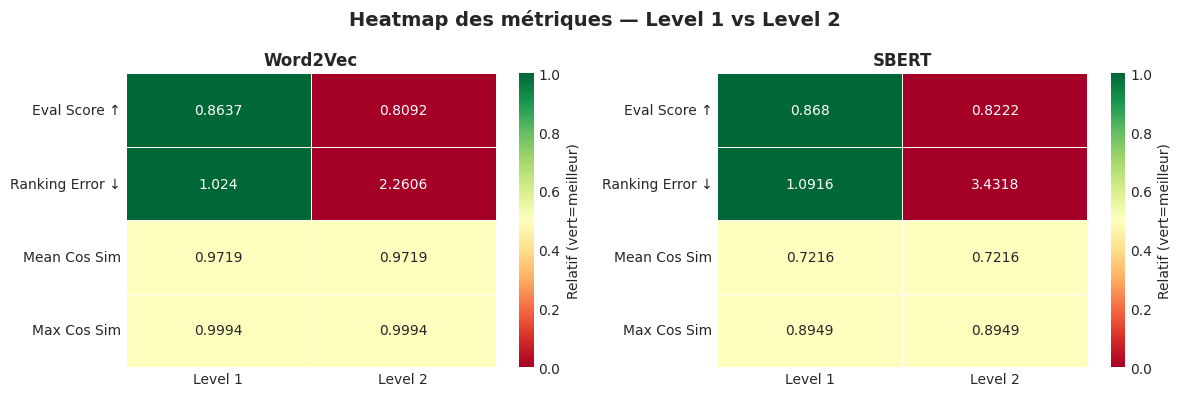

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Heatmap des métriques — Level 1 vs Level 2', fontsize=14, fontweight='bold')

metrics = ['eval_score', 'ranking_error', 'mean_cos_sim', 'max_cos_sim']
metric_labels = ['Eval Score ↑', 'Ranking Error ↓', 'Mean Cos Sim', 'Max Cos Sim']

for ax, (model_name, l1_res, l2_res) in zip(axes, [
    ('Word2Vec', w2v_l1, w2v_l2),
    ('SBERT',    sbert_l1, sbert_l2)
]):
    data = np.array([[l1_res[m], l2_res[m]] for m in metrics])
    df_heat = pd.DataFrame(data, index=metric_labels, columns=['Level 1', 'Level 2'])
    df_norm = df_heat.copy()
    for i, m in enumerate(metrics):
        row = df_heat.iloc[i]
        rng_val = row.max() - row.min()
        if rng_val > 0:
            df_norm.iloc[i] = (row - row.min()) / rng_val
        else:
            df_norm.iloc[i] = 0.5
    df_norm.iloc[1] = 1 - df_norm.iloc[1]

    sns.heatmap(df_norm, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
                annot=df_heat.round(4), fmt='', linewidths=0.5,
                cbar_kws={'label': 'Relatif (vert=meilleur)'})
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 6.3 Distribution des scores cosinus (top-1)

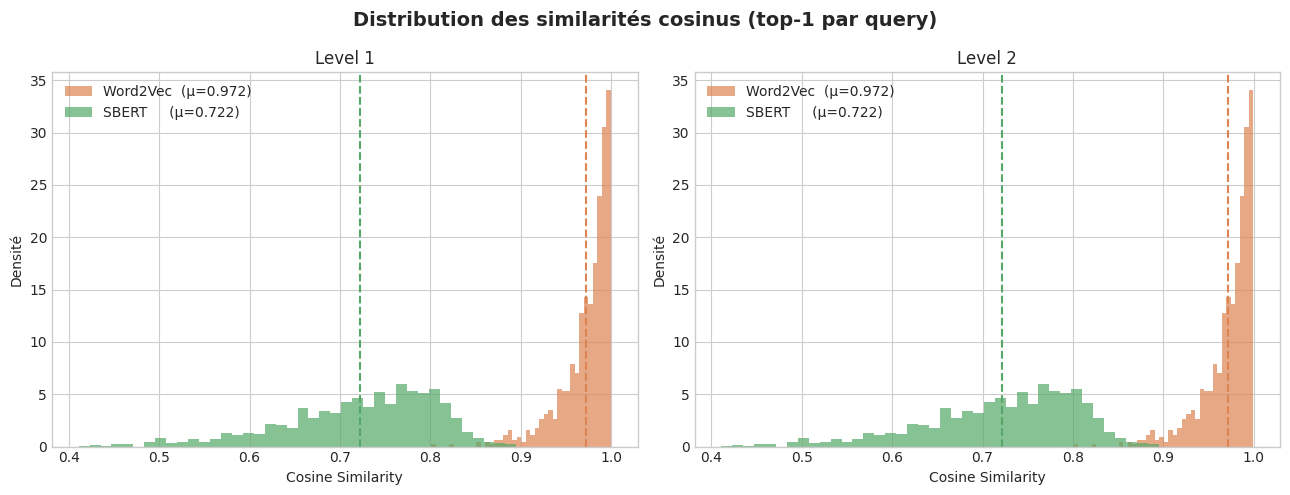

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle('Distribution des similarités cosinus (top-1 par query)', fontsize=14, fontweight='bold')

for ax, (level_label, l1_res, l2_res) in zip(axes, [
    ('Level 1', w2v_l1, sbert_l1),
    ('Level 2', w2v_l2, sbert_l2)
]):
    ax.hist(l1_res['_top1_sims'], bins=40, alpha=0.7, color=PALETTE['Word2Vec'],
            label=f'Word2Vec  (μ={np.mean(l1_res["_top1_sims"]):.3f})', density=True)
    ax.hist(l2_res['_top1_sims'], bins=40, alpha=0.7, color=PALETTE['SBERT'],
            label=f'SBERT     (μ={np.mean(l2_res["_top1_sims"]):.3f})', density=True)
    ax.axvline(np.mean(l1_res['_top1_sims']), color=PALETTE['Word2Vec'],
               linestyle='--', linewidth=1.5)
    ax.axvline(np.mean(l2_res['_top1_sims']), color=PALETTE['SBERT'],
               linestyle='--', linewidth=1.5)
    ax.set_title(f'{level_label}', fontsize=12)
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 6.4 Distribution des ranking errors

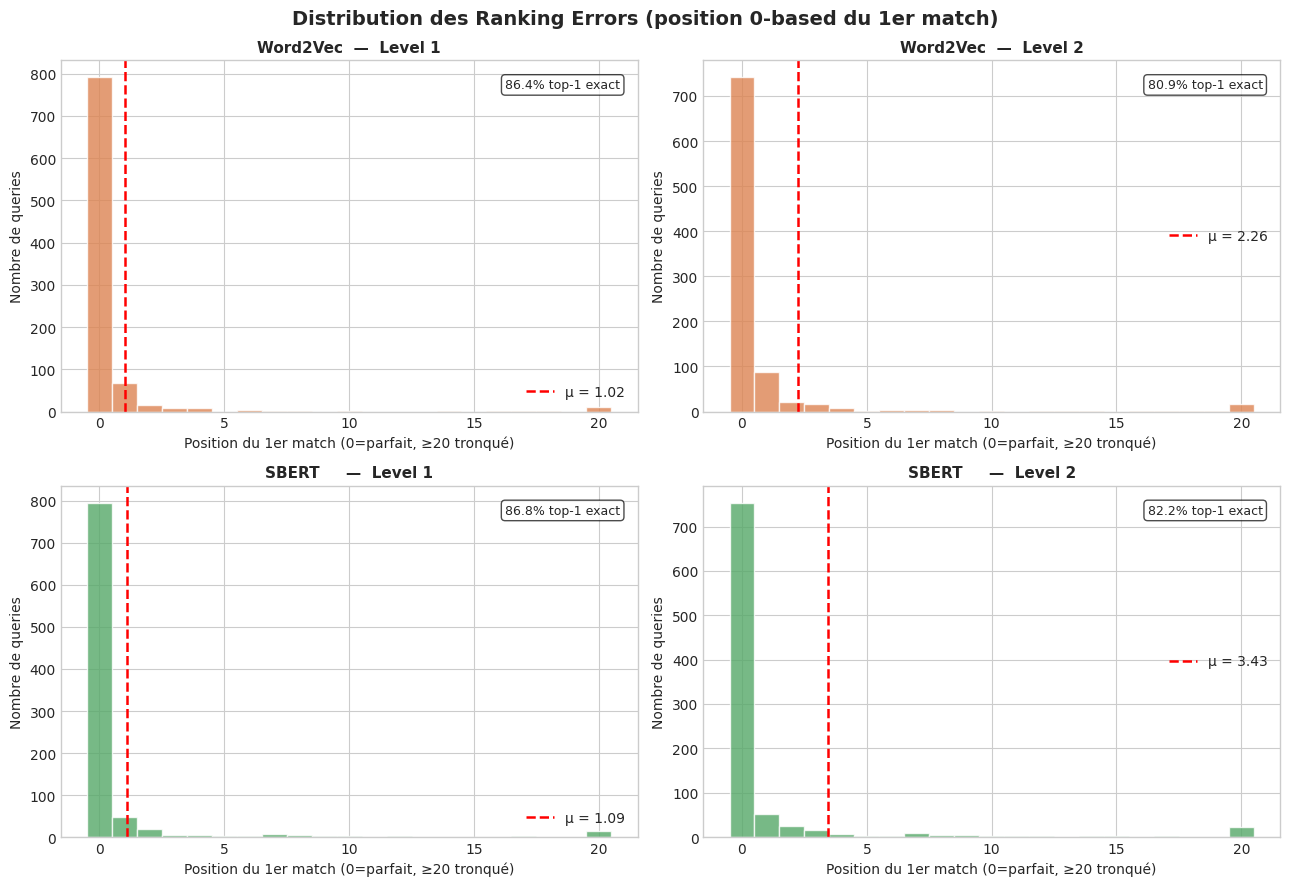

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribution des Ranking Errors (position 0-based du 1er match)',
             fontsize=14, fontweight='bold')

configs = [
    ('Word2Vec  —  Level 1', w2v_l1['_ranking_errors'],   PALETTE['Word2Vec']),
    ('Word2Vec  —  Level 2', w2v_l2['_ranking_errors'],   PALETTE['Word2Vec']),
    ('SBERT     —  Level 1', sbert_l1['_ranking_errors'], PALETTE['SBERT']),
    ('SBERT     —  Level 2', sbert_l2['_ranking_errors'], PALETTE['SBERT']),
]

for ax, (title, errors, color) in zip(axes.flat, configs):
    errors_capped = [min(e, 20) for e in errors]
    bins = np.arange(-0.5, 21.5, 1)
    ax.hist(errors_capped, bins=bins, color=color, alpha=0.8, edgecolor='white')
    mu = np.mean(errors)
    pct_zero = 100 * sum(e == 0 for e in errors) / len(errors) if errors else 0
    ax.axvline(mu, color='red', linestyle='--', linewidth=1.8, label=f'μ = {mu:.2f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Position du 1er match (0=parfait, ≥20 tronqué)')
    ax.set_ylabel('Nombre de queries')
    ax.legend(fontsize=10)
    ax.text(0.97, 0.92, f'{pct_zero:.1f}% top-1 exact',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

## 7. Exemples de requêtes top-k

In [21]:
# Lookup nom de lieu
id2nom = reviews.drop_duplicates('idplace').set_index('idplace')['nom'].to_dict()
id2type = reviews.drop_duplicates('idplace').set_index('idplace')['typeR'].to_dict()

def show_top_k_comparison(query: str, k: int = 8):
    print(f"\n{'='*65}")
    print(f"Requête : '{query}'")
    print(f"{'='*65}")

    # SBERT
    sbert_ids, sbert_scores = sbert_module.top_k_sbert(
        query, sbert_place_ids, sbert_place_vecs, sbert_model, k=k
    ).values.T
    sbert_results = pd.DataFrame({
        'Rang': range(1, k+1),
        'idplace': sbert_ids,
        'Nom': [id2nom.get(pid, '?') for pid in sbert_ids],
        'Type': [id2type.get(pid, '?') for pid in sbert_ids],
        'Score': [f"{s:.4f}" for s in sbert_scores],
    })

    #Word2Vec
    w2v_ids, w2v_scores = w2v_module.w2v_top_k_places(
        query, w2v_place_ids, w2v_place_vecs, w2v_model, k=k
    )
    w2v_results = pd.DataFrame({
        'Rang': range(1, k+1),
        'idplace': w2v_ids,
        'Nom': [id2nom.get(pid, '?') for pid in w2v_ids],
        'Type': [id2type.get(pid, '?') for pid in w2v_ids],
        'Score': [f"{s:.4f}" for s in w2v_scores],
    })
    bm25_scores_raw = bm25_module.bm25_score(query, bm25)
    reviews_with_scores = reviews.copy()
    reviews_with_scores['bm25_score'] = bm25_scores_raw
    bm25_agg = (reviews_with_scores
                .groupby('idplace')['bm25_score'].mean()
                .sort_values(ascending=False)
                .head(k))
    bm25_results = pd.DataFrame({
        'Rang': range(1, len(bm25_agg)+1),
        'idplace': bm25_agg.index,
        'Nom': [id2nom.get(pid, '?') for pid in bm25_agg.index],
        'Type': [id2type.get(pid, '?') for pid in bm25_agg.index],
        'Score': [f"{s:.4f}" for s in bm25_agg.values],
    })

    print("\n SBERT")
    display(sbert_results.set_index('Rang'))
    print("\n Word2Vec")
    display(w2v_results.set_index('Rang'))
    print("\nBM25")
    display(bm25_results.set_index('Rang'))

print("Fonction show_top_k_comparison définie")

Fonction show_top_k_comparison définie


In [25]:
show_top_k_comparison("best italian restaurant in Paris", k=8)


Requête : 'best italian restaurant in Paris'

 SBERT


,idplace,Nom,Type,Score
Rang,,,,
1,18915767.0,Ciore pizzeria napoletana,R,0.7918
2,718157.0,L'Enoteca,R,0.7450
3,1500304.0,Le Caruso,R,0.7339
4,1049698.0,Boboli,R,0.7239
5,1371470.0,Don Giovanni,R,0.7236
6,3464234.0,Ristorante Italiano 0039,R,0.7105
7,1956523.0,Gusto,R,0.7071
8,4130983.0,Auberge de Venise Bastille,R,0.7052



 Word2Vec


,idplace,Nom,Type,Score
Rang,,,,
1,18915767.0,Ciore pizzeria napoletana,R,0.8556
2,1956523.0,Gusto,R,0.8257
3,1371470.0,Don Giovanni,R,0.8207
4,718063.0,Isami Zushi,R,0.8178
5,14068772.0,Patita Negra,R,0.8175
6,14210666.0,A modo mio,R,0.8167
7,18715726.0,Kuma,R,0.8166
8,3356562.0,Thai Classic,R,0.8134



BM25


,idplace,Nom,Type,Score
Rang,,,,
1,18915767.0,Ciore pizzeria napoletana,R,7.3674
2,13142894.0,Pizza e Fichi,R,5.4633
3,6444467.0,Primo,R,4.7600
4,1371470.0,Don Giovanni,R,4.7163
5,718157.0,L'Enoteca,R,4.5871
6,15059397.0,Apprendre le français lors d'une visite à pied,AP,4.5474
7,1956523.0,Gusto,R,4.4883
8,18966875.0,Bistrot Charbon,R,4.3797


In [26]:
show_top_k_comparison("romantic hotel with good views", k=8)


Requête : 'romantic hotel with good views'

 SBERT


,idplace,Nom,Type,Score
Rang,,,,
1,11895966.0,Dîner-croisière romantique avec champagne,AP,0.6300
2,235629.0,Hôtel du Vieux Marais,H,0.5648
3,235561.0,Hotel Charles V,H,0.5408
4,235549.0,Hotel Duo,H,0.5386
5,230461.0,Hotel Paris Rivoli,H,0.5369
6,194304.0,Hotel du Jeu de Paume,H,0.5282
7,10386434.0,Hôtel de JoBo,H,0.5280
8,14966445.0,Le Rose Pompon,R,0.5263



 Word2Vec


,idplace,Nom,Type,Score
Rang,,,,
1,302993.0,Hotel le Notre Dame,H,0.7937
2,17418071.0,Don Juan II Yachts de Paris,R,0.7881
3,4567336.0,La Nouvelle Seine,R,0.7864
4,5259961.0,Peniche le Marcounet,R,0.7843
5,188738.0,Le Pavillon de la Reine,H,0.7831
6,194304.0,Hotel du Jeu de Paume,H,0.7824
7,10386434.0,Hôtel de JoBo,H,0.7787
8,188978.0,Hotel Bourg Tibourg,H,0.7777



BM25


,idplace,Nom,Type,Score
Rang,,,,
1,15029509.0,Statue de Gérard de Nerval,A,6.0223
2,16797077.0,Bus Toqué Restaurant PARIS BY NIGHT DINNER O C...,AP,5.7717
3,15304776.0,Séance de photographie privée de 90 minutes av...,AP,5.7562
4,11989870.0,Spectacle au Crazy Horse Paris et dîner Chez F...,AP,5.3237
5,302993.0,Hotel le Notre Dame,H,4.0833
6,22987001.0,Excursion privée d'une demi-journée à Versaill...,AP,3.8938
7,11485455.0,Visite privée guidée de 2 heures au musée de l...,AP,3.7165
8,17418071.0,Don Juan II Yachts de Paris,R,3.6313


In [27]:
show_top_k_comparison("art museum modern exhibition", k=8)


Requête : 'art museum modern exhibition'

 SBERT


,idplace,Nom,Type,Score
Rang,,,,
1,314440.0,Centre Pompidou,A,0.6133
2,188758.0,Musée Carnavalet - Histoire de Paris,A,0.5468
3,11887225.0,Espace d'Animation des Blancs Manteaux,A,0.5437
4,12152746.0,Billet pour le musée Grévin à Paris,AP,0.5391
5,7997886.0,Galerie de Medicis,A,0.5289
6,19942725.0,Accès coupe-file au musée d'Orsay avec l'Orang...,AP,0.5282
7,12912703.0,Visite confidentielle du Musée Yves Saint Laur...,AP,0.5189
8,12221627.0,Musée de l’Armée des Invalides dont le tombeau...,AP,0.5168



 Word2Vec


,idplace,Nom,Type,Score
Rang,,,,
1,15197723.0,Explorez la collection au Pompidou,AP,0.7160
2,314440.0,Centre Pompidou,A,0.7142
3,14189108.0,Maruani Mercier,A,0.7063
4,20189053.0,Billet coupe-file: expérience audio-guidée du ...,AP,0.6800
5,11894556.0,Visite guidée privée de 2 heures du musée Pomp...,AP,0.6796
6,15853948.0,VISITE PRIVÉE MUSÉES DU LOUVRE ET D’ORSAY – Ac...,AP,0.6746
7,188472.0,Cloître des Billettes,A,0.6712
8,12912703.0,Visite confidentielle du Musée Yves Saint Laur...,AP,0.6708



BM25


,idplace,Nom,Type,Score
Rang,,,,
1,11887225.0,Espace d'Animation des Blancs Manteaux,A,10.0497
2,15217417.0,Visite privée: bienvenue au musée d'Orsay,AP,8.8465
3,4116151.0,Centre Wallonie Bruxelles,A,8.8252
4,10458156.0,Galerie Sakura,A,8.7506
5,15853948.0,VISITE PRIVÉE MUSÉES DU LOUVRE ET D’ORSAY – Ac...,AP,8.5920
6,11473694.0,Visite privée de 2 heures sur l'art contempora...,AP,7.8308
7,17306554.0,Les impressionnistes à Orsay - sauter la ligne,AP,7.8136
8,20189053.0,Billet coupe-file: expérience audio-guidée du ...,AP,7.5309


Show top-10 recommended places for one query id

In [36]:
# pick a query place
example_id = next(iter(query_ids_eval))

def show_recos(example_id, rank_func, title):
    recos = rank_func(example_id)[:10]
    q_name = tripadvisor.loc[tripadvisor["id"] == example_id, "nom"].values
    q_name = q_name[0] if len(q_name) else "Unknown"
    q_type = meta_idx.loc[example_id, "typeR"] if example_id in meta_idx.index else "?"

    print(f"\n=== {title} ===")
    print("Query:", example_id, "|", q_name, "| typeR=", q_type)

    rows = []
    for rid in recos:
        name = tripadvisor.loc[tripadvisor["id"] == rid, "nom"].values
        name = name[0] if len(name) else "Unknown"
        rtype = meta_idx.loc[rid, "typeR"] if rid in meta_idx.index else "?"
        rows.append({"idplace": rid, "name": name, "typeR": rtype})
    display(pd.DataFrame(rows))

show_recos(example_id, rank_bm25_S1, "BM25 + S1")
show_recos(example_id, rank_bm25_S2, "BM25 + S2")
show_recos(example_id, rank_tfidf_S1, "TF-IDF + S1")
show_recos(example_id, rank_tfidf_S2, "TF-IDF + S2")


=== BM25 + S1 ===
Query: 1638400.0 | Les Gourmands de l'Ile | typeR= R


,idplace,name,typeR
0,3726842.0,La Crepe En l'Isle,R
1,1815848.0,Le Sarrasin et le Froment Creperie,R
2,5971846.0,Pain d'Epices,R
3,5924082.0,Brasserie Esmeralda,R
4,1787161.0,Cafe Med,R
5,695214.0,Brasserie de l'Isle Saint Louis,R
6,3696326.0,Bistrot Le Louis IX,R
7,2175970.0,Pom'Cannelle,R
8,2718275.0,Creperie Cat'Man,R
9,2087229.0,Le Parvis,R



=== BM25 + S2 ===
Query: 1638400.0 | Les Gourmands de l'Ile | typeR= R


,idplace,name,typeR
0,1725986.0,Le Soleil D'Or,R
1,695214.0,Brasserie de l'Isle Saint Louis,R
2,1787161.0,Cafe Med,R
3,2087229.0,Le Parvis,R
4,5924082.0,Brasserie Esmeralda,R
5,1815848.0,Le Sarrasin et le Froment Creperie,R
6,2337904.0,Le Tambour D'arcole,R
7,719116.0,Le Flore en l'Ile,R
8,718188.0,L'Orangerie Paris,R
9,3726842.0,La Crepe En l'Isle,R



=== TF-IDF + S1 ===
Query: 1638400.0 | Les Gourmands de l'Ile | typeR= R


,idplace,name,typeR
0,3726842.0,La Crepe En l'Isle,R
1,1815848.0,Le Sarrasin et le Froment Creperie,R
2,3943784.0,Sur le Pouce,R
3,12337688.0,Creperie Elo Bastille,R
4,2303907.0,La Droguerie,R
5,1905867.0,La Cidrerie du Marais,R
6,1787161.0,Cafe Med,R
7,5924082.0,Brasserie Esmeralda,R
8,5971846.0,Pain d'Epices,R
9,2718275.0,Creperie Cat'Man,R



=== TF-IDF + S2 ===
Query: 1638400.0 | Les Gourmands de l'Ile | typeR= R


,idplace,name,typeR
0,695214.0,Brasserie de l'Isle Saint Louis,R
1,1725986.0,Le Soleil D'Or,R
2,1787161.0,Cafe Med,R
3,2087229.0,Le Parvis,R
4,5924082.0,Brasserie Esmeralda,R
5,719116.0,Le Flore en l'Ile,R
6,786885.0,Cafe Hugo,R
7,1815848.0,Le Sarrasin et le Froment Creperie,R
8,718188.0,L'Orangerie Paris,R
9,2337904.0,Le Tambour D'arcole,R
